In [103]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
from scipy.optimize import minimize

In [104]:
def solve_cat_problem_v2(
    T,
    a,
    b,
    c,
    d,
    rl,
    ry,
    Il,
    Iy,
    h,
    alpha,
    beta,
    umax,
    n=200,
    animate=True,
    saveplots=False,
    saveanim=False
):
    """
    Solves the bounded-control cat-rotation problem by direct optimization.

    New problem:
        Minimize
            J[u] = ∫_0^T (K(t) + h u(t)^2) dt
                   + alpha * theta(T)^2
                   + beta  * theta_dot(T)^2

        subject to
            |u(t)| <= umax

    Dynamics:
        phi'' = u

        (Iy + Il) * theta_dot + Il * phi_dot = H0

        Hence
            theta_dot = -R * phi_dot + D,
        where
            R = Il / (Iy + Il),
            D = c + R * d

        and
            theta(t) = -R * phi(t) + D t + (a + R b)

    Notes:
        - This version uses direct optimization over a discretized control u(t),
          not solve_bvp / costates.
        - It preserves the plotting / animation behavior of solve_cat_problem_v1.
    """
    # -----------------------------
    # Imports expected by this function
    # -----------------------------
    import numpy as np
    import matplotlib.pyplot as plt
    from scipy.optimize import minimize
    from matplotlib.animation import FuncAnimation
    from IPython.display import display, HTML

    # -----------------------------
    # Physically correct constants
    # -----------------------------
    R = Il / (Iy + Il)
    D = c + R * d

    t_grid = np.linspace(0, T, n)
    dt = t_grid[1] - t_grid[0]

    # -----------------------------
    # Forward simulation from control
    # -----------------------------
    def simulate_from_control(u_vals):
        phi_vals = np.zeros(n)
        phi_dot_vals = np.zeros(n)

        phi_vals[0] = b
        phi_dot_vals[0] = d

        # semi-implicit / explicit Euler step
        for i in range(n - 1):
            phi_dot_vals[i + 1] = phi_dot_vals[i] + u_vals[i] * dt
            phi_vals[i + 1] = phi_vals[i] + phi_dot_vals[i] * dt

        theta_dot_vals = -R * phi_dot_vals + D
        theta_vals = -R * phi_vals + D * t_grid + (a + R * b)
        tail_abs_dot_vals = theta_dot_vals + phi_dot_vals

        kinetic_energy_vals = (
            0.5 * Iy * theta_dot_vals**2
            + 0.5 * Il * tail_abs_dot_vals**2
        )

        return {
            "phi": phi_vals,
            "phi_dot": phi_dot_vals,
            "theta": theta_vals,
            "theta_dot": theta_dot_vals,
            "tail_abs_dot": tail_abs_dot_vals,
            "K": kinetic_energy_vals,
        }

    # -----------------------------
    # Objective function
    # -----------------------------
    def objective(u_vals):
        sim = simulate_from_control(u_vals)

        running_cost = np.trapezoid(sim["K"] + h * u_vals**2, t_grid)

        terminal_cost = (
            alpha * sim["theta"][-1] ** 2
            + beta * sim["theta_dot"][-1] ** 2
        )

        return running_cost + terminal_cost

    # -----------------------------
    # Initial guess
    # -----------------------------
    u_guess = np.zeros(n)

    # -----------------------------
    # Hard bounds |u| <= umax
    # -----------------------------
    bounds = [(-umax, umax)] * n

    # -----------------------------
    # Optimize
    # -----------------------------
    optimization_result = minimize(
        objective,
        u_guess,
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": 1000, "ftol": 1e-10}
    )

    if not optimization_result.success:
        print("Warning: optimization did not report convergence.")
        print(optimization_result.message)

    # -----------------------------
    # Extract optimal solution
    # -----------------------------
    control_vals = optimization_result.x
    sim = simulate_from_control(control_vals)

    t_vals = t_grid
    phi_vals = sim["phi"]
    phi_dot_vals = sim["phi_dot"]
    theta_vals = sim["theta"]
    theta_dot_vals = sim["theta_dot"]
    tail_abs_dot_vals = sim["tail_abs_dot"]
    kinetic_energy_vals = sim["K"]

    terminal_cost_val = (
        alpha * theta_vals[-1] ** 2
        + beta * theta_dot_vals[-1] ** 2
    )
    running_cost_val = np.trapezoid(kinetic_energy_vals + h * control_vals**2, t_vals)
    total_cost_val = running_cost_val + terminal_cost_val

    # -----------------------------
    # Plot helper
    # -----------------------------
    def maybe_save(fig, filename):
        if saveplots:
            fig.savefig(filename, dpi=300, bbox_inches="tight")

    # theta(t)
    fig_theta, ax_theta = plt.subplots()
    ax_theta.plot(t_vals, theta_vals)
    ax_theta.set_title(r"$\theta(t)$")
    ax_theta.set_xlabel("t")
    ax_theta.set_ylabel(r"$\theta$")
    maybe_save(fig_theta, "theta_plotv2v2_v2.png")
    plt.show()

    # phi(t)
    fig_phi, ax_phi = plt.subplots()
    ax_phi.plot(t_vals, phi_vals)
    ax_phi.set_title(r"$\phi(t)$")
    ax_phi.set_xlabel("t")
    ax_phi.set_ylabel(r"$\phi$")
    maybe_save(fig_phi, "phi_plot_v2.png")
    plt.show()

    # theta_dot(t)
    fig_theta_dot, ax_theta_dot = plt.subplots()
    ax_theta_dot.plot(t_vals, theta_dot_vals)
    ax_theta_dot.set_title(r"$\dot{\theta}(t)$")
    ax_theta_dot.set_xlabel("t")
    ax_theta_dot.set_ylabel(r"$\dot{\theta}$")
    maybe_save(fig_theta_dot, "theta_dot_plot_v2.png")
    plt.show()

    # phi_dot(t)
    fig_phi_dot, ax_phi_dot = plt.subplots()
    ax_phi_dot.plot(t_vals, phi_dot_vals)
    ax_phi_dot.set_title(r"$\dot{\phi}(t)$")
    ax_phi_dot.set_xlabel("t")
    ax_phi_dot.set_ylabel(r"$\dot{\phi}$")
    maybe_save(fig_phi_dot, "phi_dot_plot_v2.png")
    plt.show()

    # u(t)
    fig_control, ax_control = plt.subplots()
    ax_control.plot(t_vals, control_vals)
    ax_control.set_title(r"$u(t)=\ddot{\phi}(t)$")
    ax_control.set_xlabel("t")
    ax_control.set_ylabel("u")
    maybe_save(fig_control, "control_plot_v2.png")
    plt.show()

    # K(t)
    fig_kinetic, ax_kinetic = plt.subplots()
    ax_kinetic.plot(t_vals, kinetic_energy_vals)
    ax_kinetic.set_title(r"$K(t)$")
    ax_kinetic.set_xlabel("t")
    ax_kinetic.set_ylabel("K")
    maybe_save(fig_kinetic, "kinetic_energy_plot_v2.png")
    plt.show()

    # -----------------------------
    # Animation
    # -----------------------------
    animation_object = None

    if animate:
        max_frames = 120
        frame_stride = max(1, len(t_vals) // max_frames)

        t_anim = t_vals[::frame_stride]
        theta_anim = theta_vals[::frame_stride]
        phi_anim = phi_vals[::frame_stride]

        fig_anim, ax_anim = plt.subplots(figsize=(5, 5))
        ax_anim.set_xlim(-2.2, 2.2)
        ax_anim.set_ylim(-2.2, 2.2)
        ax_anim.set_aspect("equal")
        ax_anim.set_title("Courtney Animation")

        body_patch = plt.Circle((0, 0), 1.0, fill=True, color="saddlebrown", alpha=0.8)
        ax_anim.add_patch(body_patch)

        eye_left_plot, = ax_anim.plot([], [], "o", markersize=4, color="black")
        eye_right_plot, = ax_anim.plot([], [], "o", markersize=4, color="black")
        mouth_plot, = ax_anim.plot([], [], lw=2, color="red")
        hat_brim_plot, = ax_anim.plot([], [], lw=7, color="black")
        hat_top_plot, = ax_anim.plot([], [], lw=10, color="black")
        tail_plot, = ax_anim.plot([], [], lw=3, color="black")

        tail_length = rl

        ground_line, = ax_anim.plot([], [], lw=3, color="green")

        g_ground = 21.44
        ground_y0 = -0.99 - 0.5 * g_ground * T**2
        x_ground = np.array([-3.0, 3.0])

        def update(frame_index):
            theta = theta_anim[frame_index]
            phi = phi_anim[frame_index]

            rotation_matrix = np.array([
                [np.cos(theta), -np.sin(theta)],
                [np.sin(theta),  np.cos(theta)]
            ])

            body_up = rotation_matrix @ np.array([0.0, 1.0])
            body_right = rotation_matrix @ np.array([1.0, 0.0])

            # Eyes
            left_eye = rotation_matrix @ np.array([-0.18, 0.15])
            right_eye = rotation_matrix @ np.array([0.18, 0.15])
            eye_left_plot.set_data([left_eye[0]], [left_eye[1]])
            eye_right_plot.set_data([right_eye[0]], [right_eye[1]])

            # Smile
            smile_s = np.linspace(-1.0, 1.0, 30)
            smile_local = np.vstack([
                0.12 * smile_s,
                -0.18 + 0.04 * smile_s**2
            ])
            smile_points = rotation_matrix @ smile_local
            mouth_plot.set_data(smile_points[0], smile_points[1])

            # Hat
            hat_center = 1.02 * body_up
            hat_half_width = 0.45
            hat_height = 0.14

            brim_left = hat_center - hat_half_width * body_right
            brim_right = hat_center + hat_half_width * body_right
            hat_brim_plot.set_data(
                [brim_left[0], brim_right[0]],
                [brim_left[1], brim_right[1]]
            )

            top_center = hat_center + hat_height * body_up
            top_left = top_center - 0.16 * body_right
            top_right = top_center + 0.16 * body_right
            hat_top_plot.set_data(
                [top_left[0], top_right[0]],
                [top_left[1], top_right[1]]
            )

            # Tail
            tail_absolute_angle = theta + phi + np.pi/2
            tail_base = np.array([0.0, 0.0])
            tail_tip = tail_length * np.array([
                np.cos(tail_absolute_angle),
                np.sin(tail_absolute_angle)
            ])

            tail_plot.set_data(
                [tail_base[0], tail_tip[0]],
                [tail_base[1], tail_tip[1]]
            )

            t_current = t_anim[frame_index]
            ground_y = ground_y0 + 0.5 * g_ground * t_current**2
            ground_line.set_data(x_ground, [ground_y, ground_y])

            return (
                eye_left_plot,
                eye_right_plot,
                mouth_plot,
                hat_brim_plot,
                hat_top_plot,
                tail_plot,
                ground_line,
            )

        n_frames = len(theta_anim)
        interval = (T / max(n_frames, 1)) * 1000

        animation_object = FuncAnimation(
            fig_anim,
            update,
            frames=n_frames,
            interval=interval,
            blit=True
        )

        maybe_save(fig_anim, "cat_animation_first_frame_v2.png")

        if saveanim:
            from matplotlib.animation import FFMpegWriter

            fps = max(1, int(n_frames / T))
            writer = FFMpegWriter(fps=fps, bitrate=1800)
            animation_object.save("cat_animation_v2.mp4", writer=writer)

        video = animation_object.to_html5_video()
        video = video.replace("loop", "")
        display(HTML(video))
        plt.close(fig_anim)

    return {
        "optimization_result": optimization_result,
        "t": t_vals,
        "theta": theta_vals,
        "phi": phi_vals,
        "theta_dot": theta_dot_vals,
        "phi_dot": phi_dot_vals,
        "tail_abs_dot": tail_abs_dot_vals,
        "u": control_vals,
        "K": kinetic_energy_vals,
        "R": R,
        "D": D,
        "alpha": alpha,
        "beta": beta,
        "umax": umax,
        "running_cost": running_cost_val,
        "terminal_cost": terminal_cost_val,
        "total_cost": total_cost_val,
    }

In [105]:
T = 1.7
a = np.pi
b = 0
c = 0
d = 0

m = 1.0      # tail-end mass
M = 20.0     # body mass
rl = 1.5     # tail length
ry = 1.0     # body radius

Il = m * rl**2
Iy = 0.5 * M * ry**2

h = 1.0
alpha=1000
beta=200
umax=6*np.pi

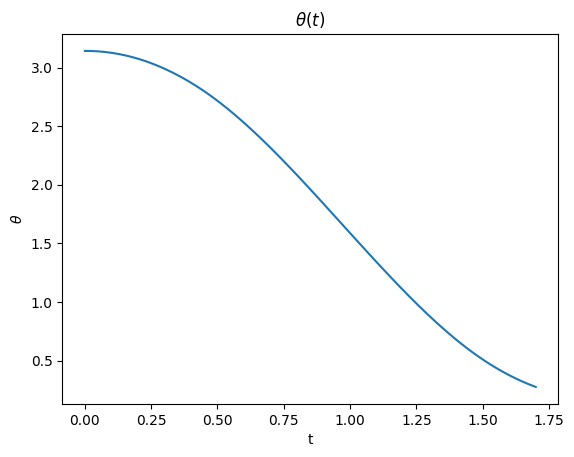

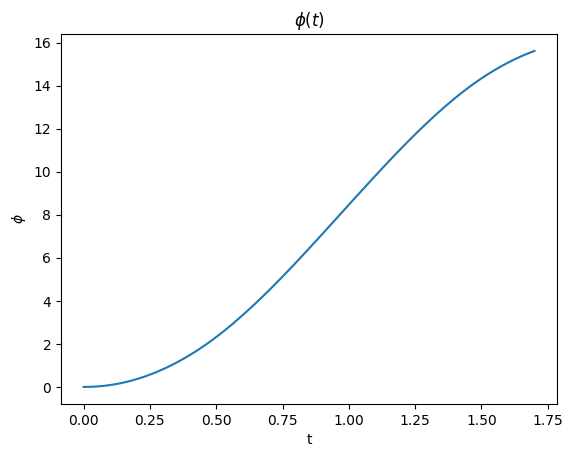

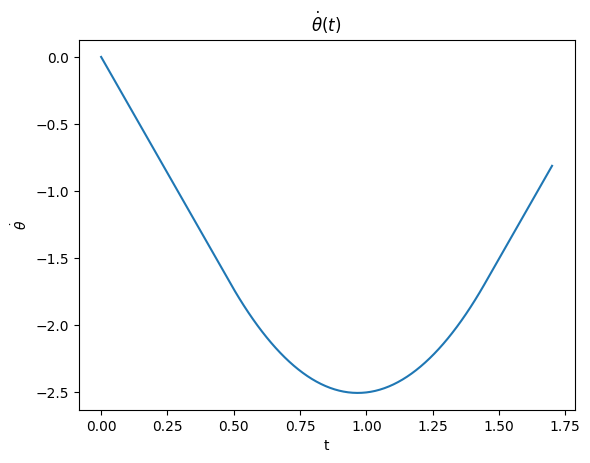

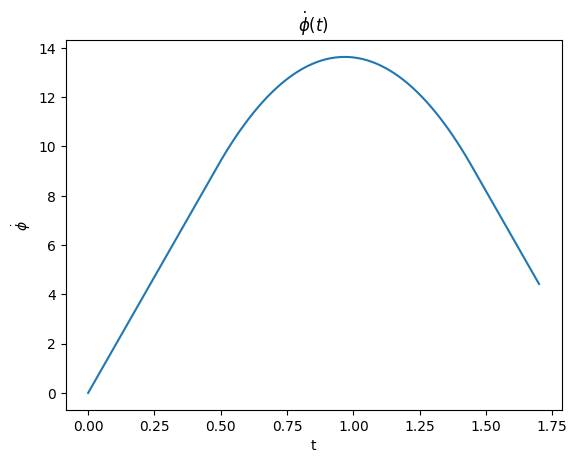

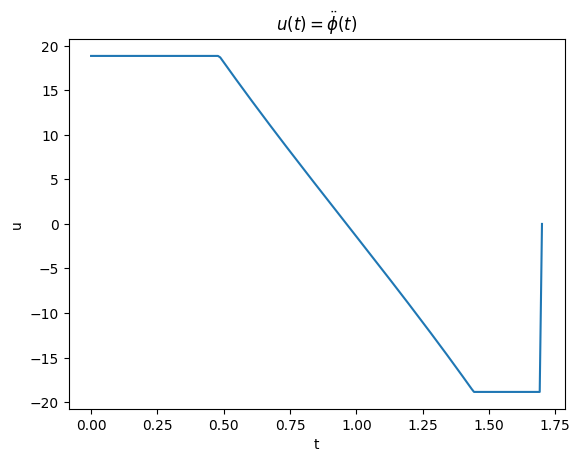

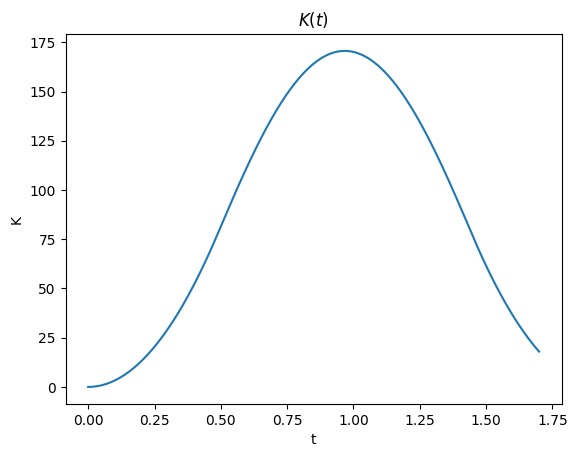

{'optimization_result':   message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
   success: True
    status: 0
       fun: 734.7655611484449
         x: [ 1.885e+01  1.885e+01 ... -1.885e+01  0.000e+00]
       nit: 22
       jac: [-5.421e-01 -3.738e-01 ...  1.876e-01  0.000e+00]
      nfev: 5427
      njev: 27
  hess_inv: <200x200 LbfgsInvHessProduct with dtype=float64>,
 't': array([0.        , 0.00854271, 0.01708543, 0.02562814, 0.03417085,
        0.04271357, 0.05125628, 0.05979899, 0.06834171, 0.07688442,
        0.08542714, 0.09396985, 0.10251256, 0.11105528, 0.11959799,
        0.1281407 , 0.13668342, 0.14522613, 0.15376884, 0.16231156,
        0.17085427, 0.17939698, 0.1879397 , 0.19648241, 0.20502513,
        0.21356784, 0.22211055, 0.23065327, 0.23919598, 0.24773869,
        0.25628141, 0.26482412, 0.27336683, 0.28190955, 0.29045226,
        0.29899497, 0.30753769, 0.3160804 , 0.32462312, 0.33316583,
        0.34170854, 0.35025126, 0.35879397, 0.36733668, 0.3758794 ,
 

In [106]:
solve_cat_problem_v2(
    T,
    a,
    b,
    c,
    d,
    rl,
    ry,
    Il,
    Iy,
    h,
    alpha=alpha,
    beta=beta,
    umax=umax,
    n=200,
    animate=True,
    saveplots=True,
    saveanim=True
)